# F1: Leak

This appendix deals with leak current in whole-cell patch clamp.

In the literature, the term "leak current" is sometimes used to describe currents through "leak channels" such as TASK (potassium), ClC (chloride), or NALCN (sodium), see e.g. [Huang et al., 2015](https://doi.org/10.3389/fncel.2015.00432).
Alternatively, it can mean the leak through an imperfect seal.

Here, we focus on the second definition.

## Simple linear model

A simple model of leak current is
\begin{align}
I_\text{leak} = g_\text{leak} (V_m - E_\text{leak})
\end{align}

## Leak conductance

Inverse of resistance.

Not the inverse of series resistance $R_s$, see below.

## Leak is proportional to Vm

Below are three sketches of a patch, each representing an idea of how leak may arise.

<img src="./img/leak.png" style="margin: auto"/>

In the first schematic, leak is from inside the pipette, after most of the series resistance $g_e$, but before a small final resistance $g_c$.

In the second schematic, some dirt or debris from rupturing the membrane has created an imperfect seal, creating a pathway from inside the cell to the bath.

The final schematic allows both.

Studies (summarised in [Malboubi 2011](https://etheses.bham.ac.uk/id/eprint/3137/1/Malboubi11PhD.pdf) suggest that - before rupturing the membrane - the situation is most like the first drawing.

Note that we have not includded batteries in either pathway, making this a leak model with $E_\text{leak} = 0$.

### Simple model

So far, we have used.

\begin{align}
C_m \dot{V}_m = \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} - I - g_\text{leak} (V - E_\text{leak})
\end{align}

This is equivalent to the situation above if $g_1 = 0$ and $E_\text{leak} = 0$.

### Double leak model

Analysing the $V_1$ node in the schematic above, we find
\begin{align}
g_e (V_p + E_\text{off}^\dagger - V_1) &= g_1 V_1 + g_c (V_1 - V_m) \\
V_1 &= \frac{g_e (V_p + E_\text{off}^\dagger) + g_c V_m}{g_1 + g_c + g_e}
\end{align}

At the $V_m$ node
\begin{align}
C_m \dot{V}_m + I + g_2 V_m
&= g_c (V_1 - V_m) \\
&= g_c \frac{g_e (V_p + E_\text{off}^\dagger) + g_c V_m}{g_1 + g_c + g_e} - g_c V_m \\
&= \frac{g_e g_c (V_p + E_\text{off}^\dagger) - g_c g_1 V_m - g_c g_e V_m}{g_1 + g_c + g_e} \\
&= \frac{g_e g_c}{g_1 + g_c + g_e}(V_p + E_\text{off}^\dagger - V_m) - \frac{g_c g_1}{g_1 + g_c + g_e} V_m
\end{align}
Rearranging to the original form
\begin{align}
C_m \dot{V}_m = \frac{g_e g_c}{g_1 + g_c + g_e}(V_p + E_\text{off}^\dagger - V_m) - \frac{g_c g_1}{g_1 + g_c + g_e} V_m - g_2 V_m - I
\end{align}
Equating the two equations we find
\begin{align}
R_s &= \frac{g_1 + g_c + g_e}{g_e g_c} \\
g_\text{leak} &= \frac{g_c g_1}{g_1 + g_c + g_e} + g_2 \\
E_\text{leak} &= 0
\end{align}

So all three models end up as some $g$ times $V$.

### Reduction to simple model

Setting $g_1 = 0$ reduces this to our original model, with
\begin{align}
g_\text{leak} = g_2
\end{align}
and
\begin{align}
R_s &= \frac{g_c + g_e}{g_e g_c} = \frac{1}{g_e} + \frac{1}{g_c} \\
\end{align}
which is just the rule for resistors in series.

### Reduction to series resistance

Conversely, setting $g_2 = 0$ gives
\begin{align}
g_\text{leak} = 1 / R_s
\end{align}

In this model, with no leak from the cell and no $E_\text{leak}$, 

## Why is there an E-leak?

Using linear regression to fit straight lines through currents from "leak ramps" (voltage protocol sections at voltages unlikely to open channels), we found a cell-to-cell varying, non-zero $E_\text{leak}$.

Linear regression will always give some offset though, so need to test if $E$ really necessary or good fit can be achieved with E=0

Is this physically justifiable?
A common argument is that, if the current is non-specific, it should reverse at zero.
See for example [Wilson et al. 2011](https://doi.org/10.4161/chan.5.6.17484).



If the current is selective, e.g. only small ions can pass through, then there could be an $E$.
(But this would be the same for every cell).

If only sodium, potassium, and chloride can pass, we can write a GHK voltage equation:

\begin{align}
E = \frac{RT}{F} \log \left(
\frac{P_\text{Na} [\text{Na}^+]_e + P_\text{K} [\text{K}^+]_e + P_\text{Cl} [\text{Cl}^-]_e}{P_\text{Na} [\text{Na}^+]_i + P_\text{K} [\text{K}^+]_i + P_\text{Cl} [\text{Cl}^-]_i}
\right)
\end{align}

Assuming equal permeability, in a typical solution we might find
\begin{align}
E = \frac{RT}{F} \log \left(\frac{140 + 4 + 148}{0 + 130 + 134}\right)
  \approx 25 \cdot \log 1.12 
  \approx 3\,\text{mV}
\end{align}

In general, we expect bath and pipette solutions to have similar osmolarity, and so a similar number of solutes.
But because e.g. EGTA and ATP are more commonly added to pipette solution, this might have fewer monovalent ions and so a positive $E$.

This current would also be quite linear:

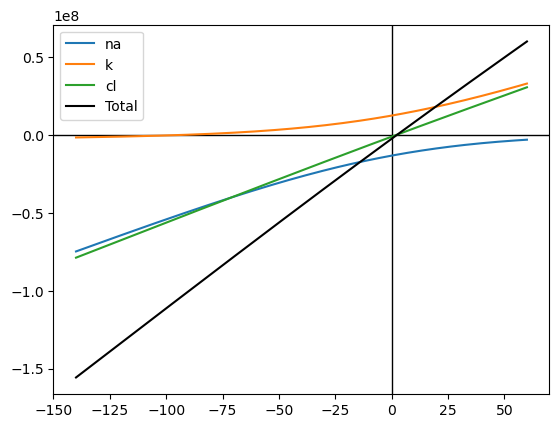

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def ghk(v):
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.axhline(0, color='k', lw=1)
    ax.axvline(0, color='k', lw=1)
    
    ions = {
        # external, internal, valence, permability
        'na': (140, 0, 1, 1),
        'k': (4, 130, 1, 1),
        'cl': (148, 134, 1, 1),
    }
    R = 8314  # J/kmol/K
    T = 294   # K, 21C
    F = 96485 # C/mol
    FRT = F / (R * T)
    FFRT = F * FRT
    
    i = np.zeros(v.shape)
    for ion, (Ce, Ci, z, P) in ions.items():
        e = np.exp(-z * v * FRT)
        c = P * z**2 * v * FFRT * (Ci - Ce * e) / (1 - e)
        i += c
        ax.plot(v, c, label=ion)
        
    ax.plot(v, i, 'k', label='Total')
    ax.legend()
    plt.show()

v = np.linspace(-140, 60, 160)
ghk(v)


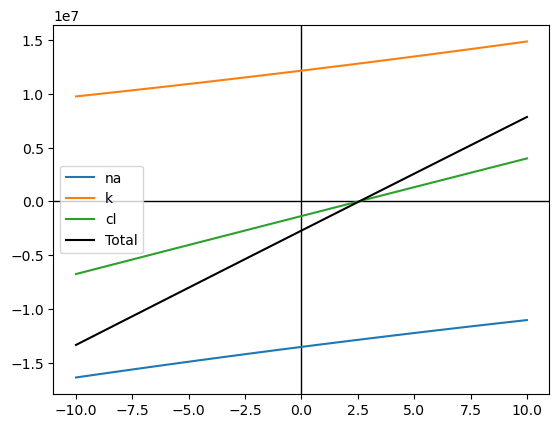

In [4]:
v = np.linspace(-10, 10)
ghk(v)

"Leak" channels can be specific or non-specific.
The sodium potassium pump could contribute a non-zero current at V=0. 

### Reversal at "zero"

For leak reversing at zero, voltage offsets do still complicate matters.

First, since contact is from pipette (filled w pipette solution) to bath, there will be an LJP, and this will be zeroed at the start of the experiment.
However, unlike the pipette-to-bath surface, this LJP will remain throughout the experiment so that no LJP correction is needed.

If there is an $E_\text{off}$, this should also be factored in.
(This would vary cell to cell.)

See also:
- Endogeneous currents
- Gating currents? (~100x smaller than ionic currents)
- Protocols to remove or quantify "leak"
  - Subtraction protocol
  - Leak ramp
- Osmotic pressure causing the cell to shrink or swell